Starting PSK Modulation Scheme Analysis...

1. Generating constellation diagrams...

2. Comparing spectral efficiency...

3. Analyzing bandwidth requirements...

4. Analyzing BER performance...
Simulating 4-PSK BER performance...
Simulating 8-PSK BER performance...
Simulating 16-PSK BER performance...
Simulating 32-PSK BER performance...

5. Calculating SNR requirements...

6. Visualizing application scenarios...

7. Creating summary table...

Summary Table:
  Modulation  Spectral Efficiency (bits/s/Hz)  Bandwidth for 1 Mbps (MHz)  \
0      4-PSK                              2.0                       0.750   
1      8-PSK                              3.0                       0.500   
2     16-PSK                              4.0                       0.375   
3     32-PSK                              5.0                       0.300   

   SNR for BER=0.0001 (dB)  
0                 8.378906  
1                11.777344  
2                16.113281  
3                21.035156  

Savin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

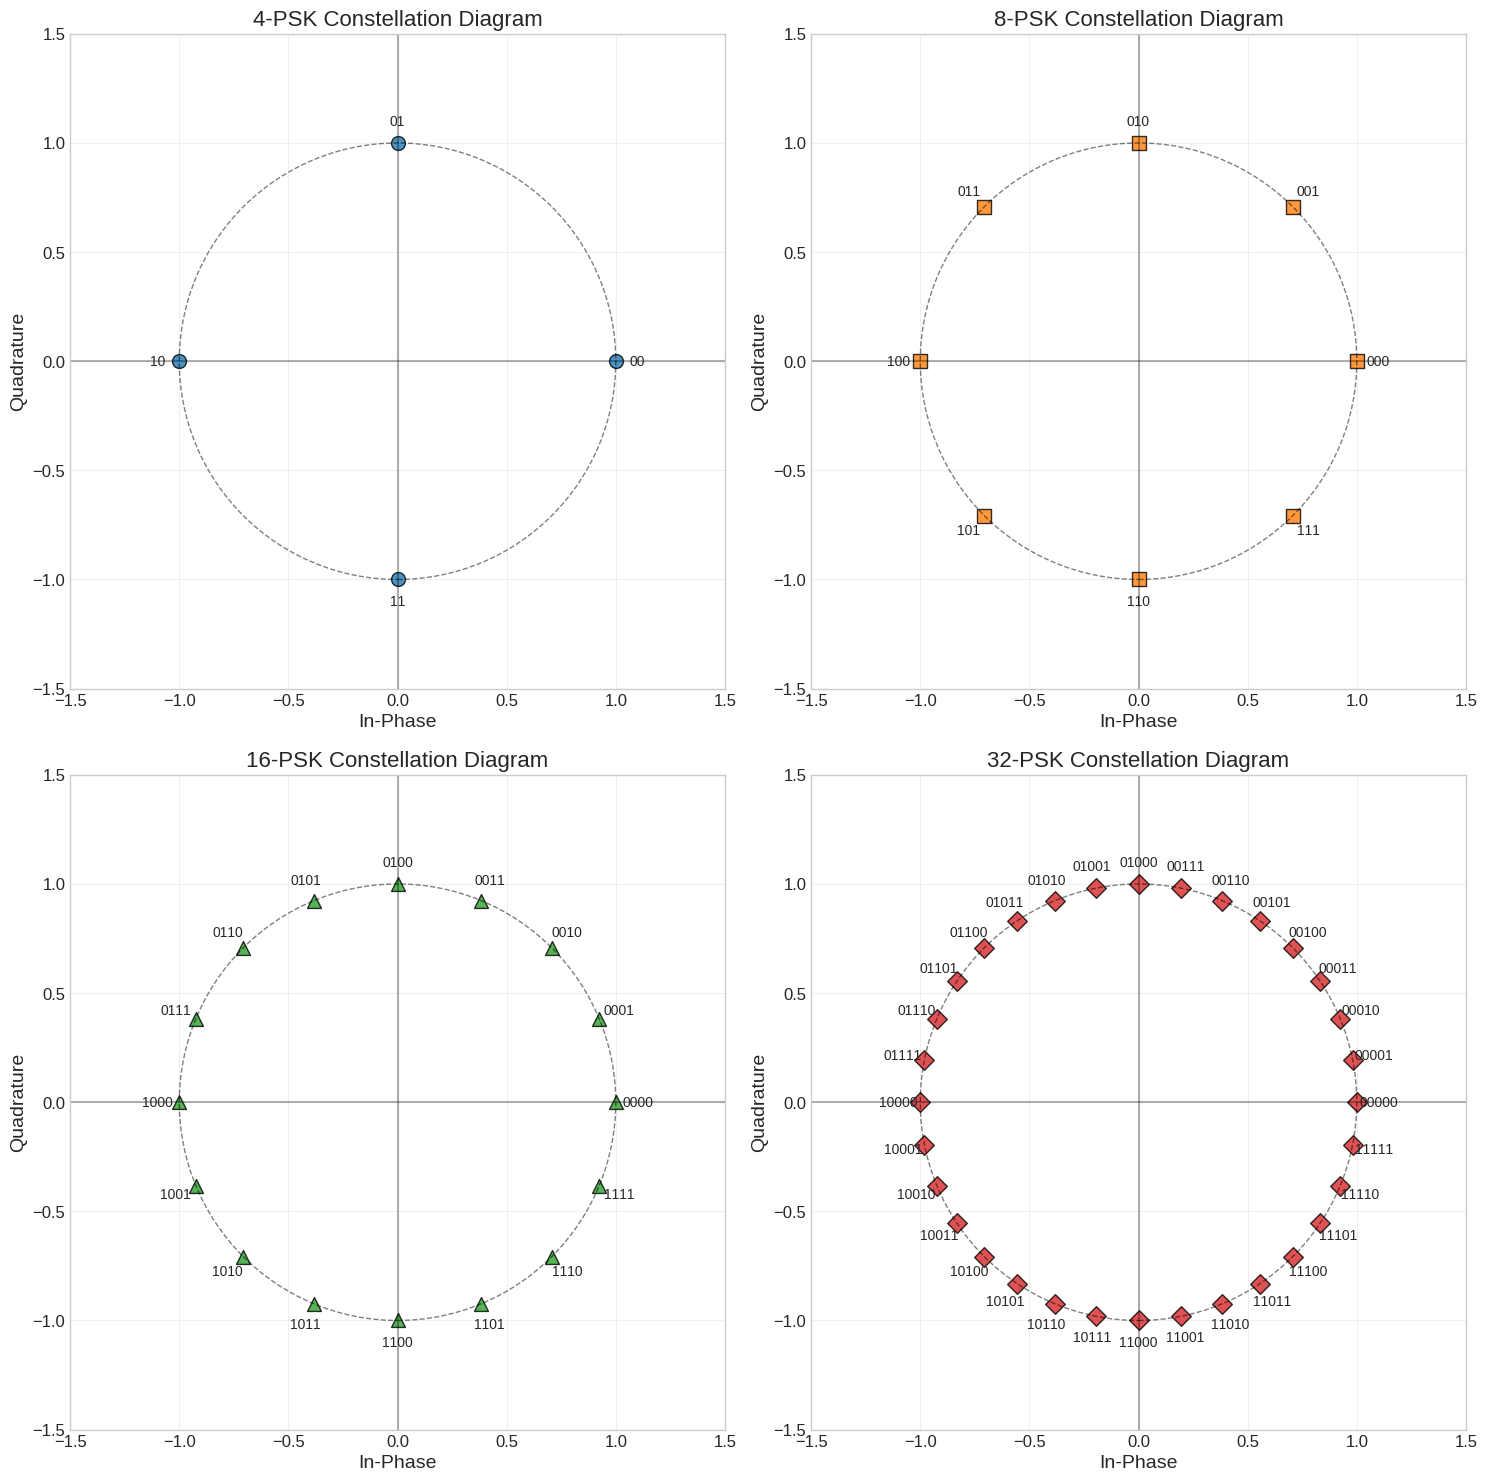

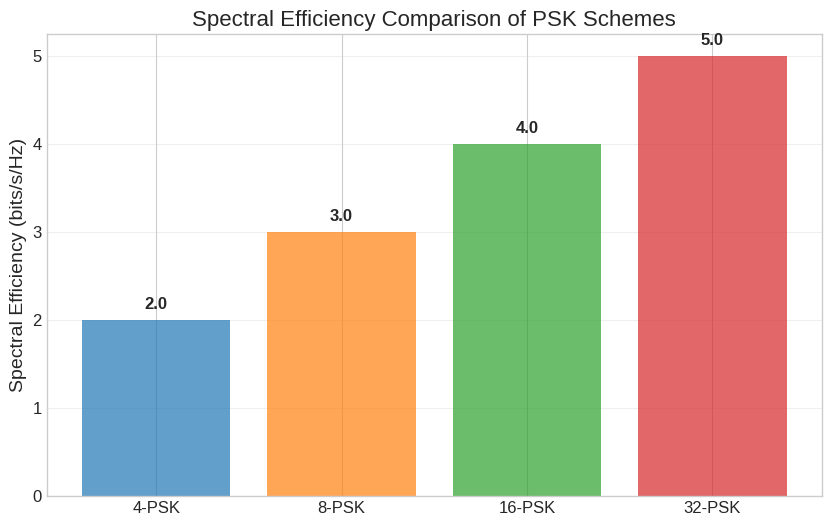

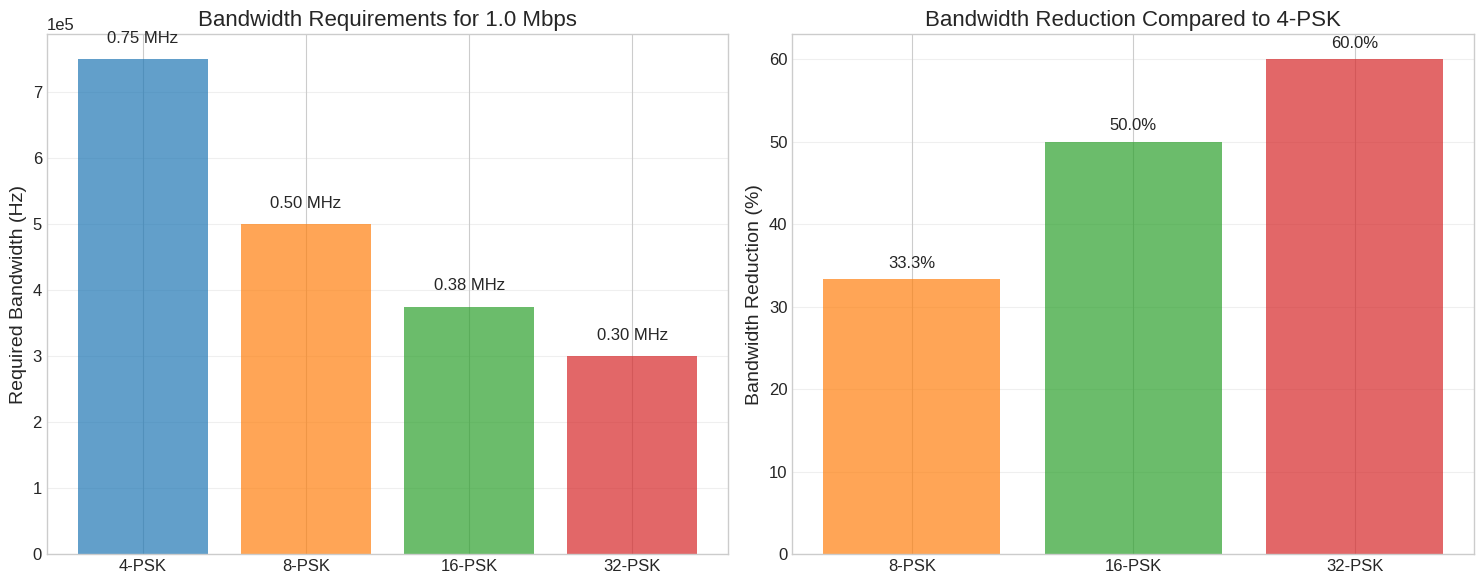

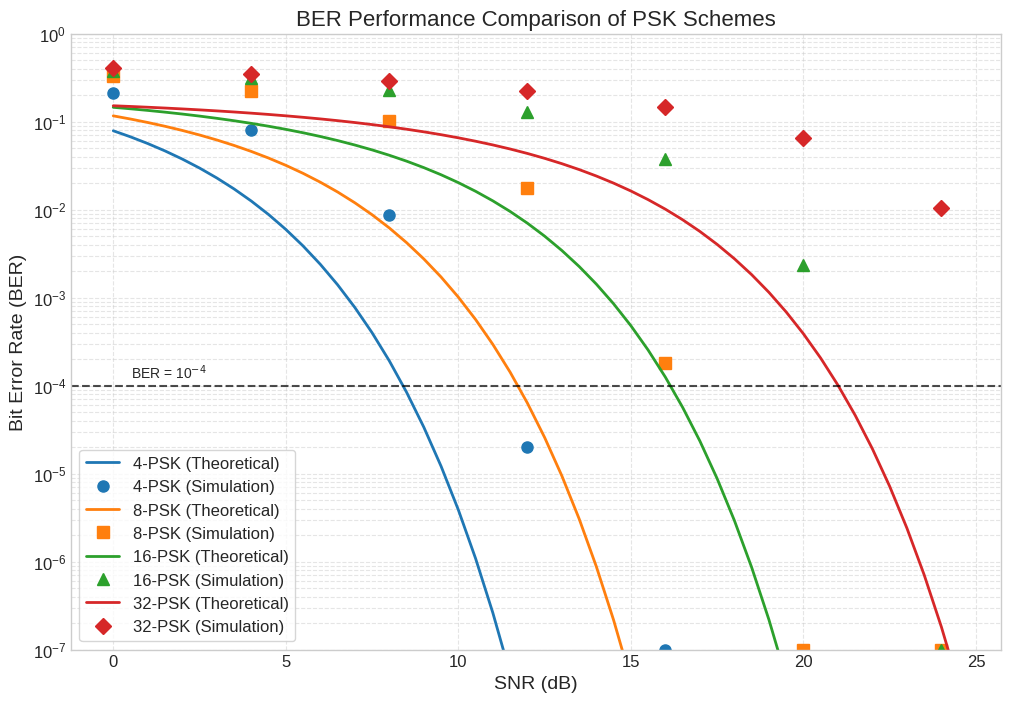

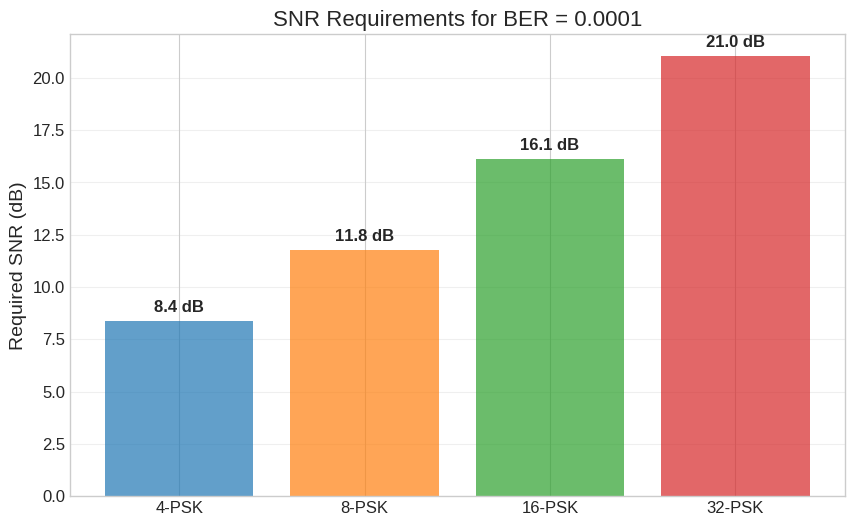

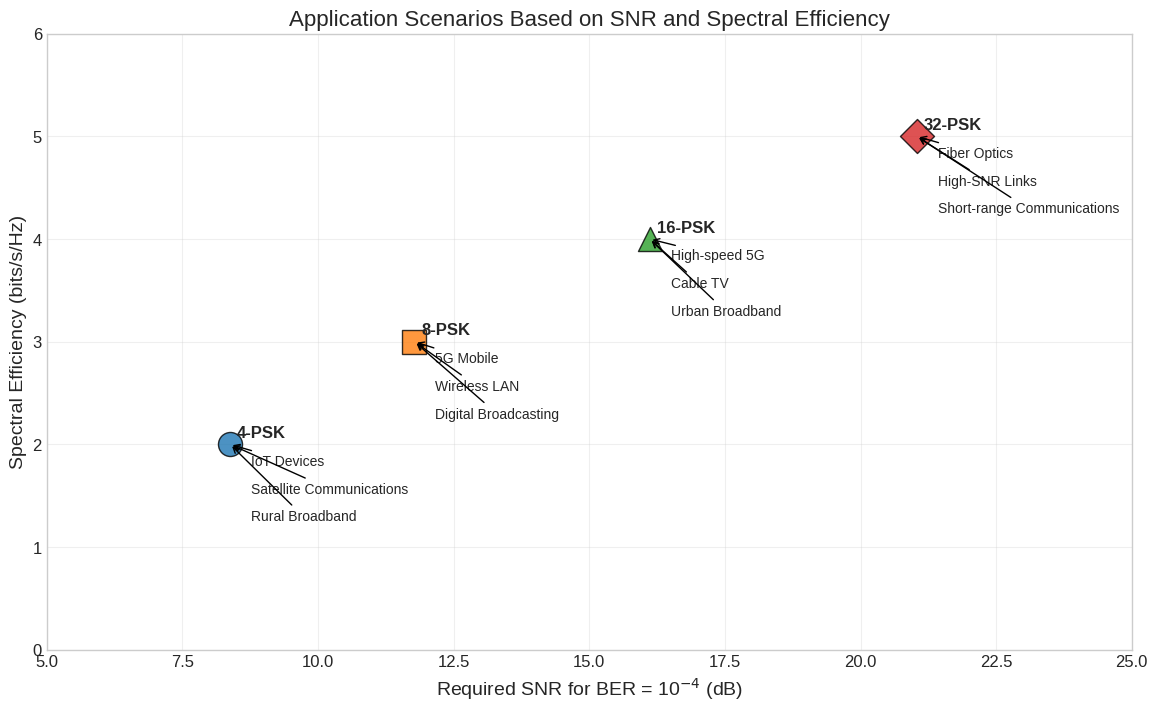

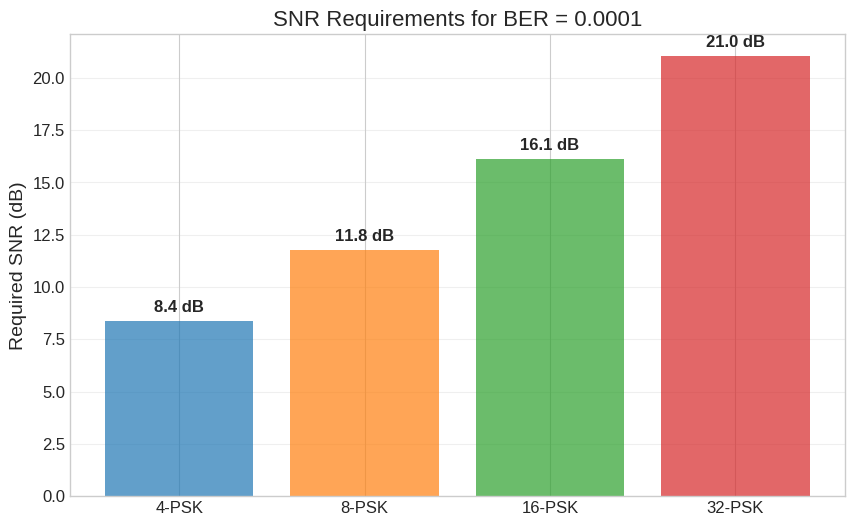

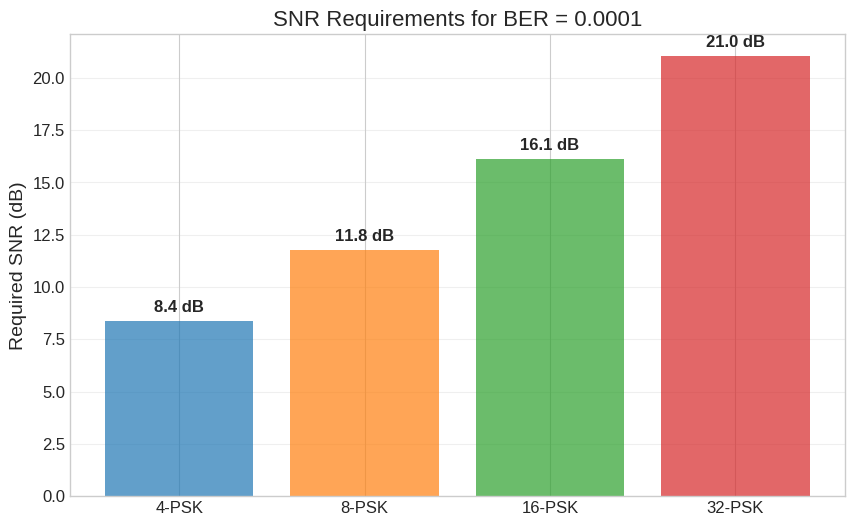

In [ ]:
"""
Comparative Analysis of Spectral Efficiency, Bandwidth Utilization, and Error Performance
in 4PSK, 8PSK, 16PSK, and 32PSK Modulation Schemes

Implementation for Colab Environment
Author: Francesco De Florence
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy import special
import pandas as pd
from google.colab import files
import io
import time

# Enable inline plotting for Colab
%matplotlib inline

# Set overall figure style and size
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.frameon': True,
    'legend.framealpha': 0.8
})

# Color scheme for consistent representation
colors = {
    '4PSK': '#1f77b4',   # Blue
    '8PSK': '#ff7f0e',   # Orange
    '16PSK': '#2ca02c',  # Green
    '32PSK': '#d62728'   # Red
}

markers = {
    '4PSK': 'o',
    '8PSK': 's',
    '16PSK': '^',
    '32PSK': 'D'
}

# Part 1: Theoretical Background Functions

def theoretical_spectral_efficiency(M):
    """Calculate theoretical spectral efficiency in bits/s/Hz"""
    return np.log2(M)

def calculate_bandwidth(symbol_rate, roll_off=0.5):
    """Calculate required bandwidth with given roll-off factor"""
    return symbol_rate * (1 + roll_off)

def calculate_symbol_rate(bit_rate, M):
    """Calculate symbol rate for given bit rate and modulation order"""
    return bit_rate / np.log2(M)

def theoretical_BER_MPSK(M, SNR_dB):
    """
    Calculate theoretical BER for M-PSK in AWGN
    Using the approximate formula: Pb ≈ (2/log2(M)) * Q(√(2*log2(M)*SNR*sin(π/M)))
    """
    SNR_linear = 10**(SNR_dB/10)
    k = np.log2(M)

    # Q-function calculation using erfc
    argument = np.sqrt(2 * k * SNR_linear * np.sin(np.pi/M)**2)
    BER = (2/k) * 0.5 * special.erfc(argument/np.sqrt(2))

    return BER

# Part 2: PSK Modulation Implementation

class PSKModulation:
    def __init__(self, M):
        """Initialize PSK modulation with M constellation points"""
        self.M = M
        self.k = int(np.log2(M))  # Bits per symbol
        self.constellation = self._generate_constellation()

    def _generate_constellation(self):
        """Generate constellation points for M-PSK"""
        phases = np.array([2*np.pi*i/self.M for i in range(self.M)])
        # Generate complex constellation points
        constellation = np.exp(1j * phases)
        return constellation

    def plot_constellation(self, ax=None):
        """Plot the constellation diagram"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 8))

        # Plot constellation points
        ax.scatter(np.real(self.constellation), np.imag(self.constellation),
                   s=100, c=colors[f'{self.M}PSK'], marker=markers[f'{self.M}PSK'],
                   edgecolors='black', alpha=0.8, label=f'{self.M}-PSK')

        # Plot unit circle
        circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', alpha=0.5)
        ax.add_patch(circle)

        # Add labels for each constellation point
        for i, point in enumerate(self.constellation):
            binary_label = format(i, f'0{self.k}b')
            ax.annotate(binary_label, (np.real(point)*1.1, np.imag(point)*1.1),
                        fontsize=10, ha='center', va='center')

        # Set axis limits and labels
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_xlabel('In-Phase')
        ax.set_ylabel('Quadrature')
        ax.set_title(f'{self.M}-PSK Constellation Diagram')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

        return ax

    def modulate(self, bit_sequence):
        """
        Modulate bit sequence using M-PSK

        Parameters:
        bit_sequence: Binary sequence to modulate

        Returns:
        Complex symbols representing modulated signal
        """
        # Ensure bit sequence length is multiple of k
        padded_length = int(np.ceil(len(bit_sequence) / self.k) * self.k)
        padded_bits = np.pad(bit_sequence, (0, padded_length - len(bit_sequence)))

        # Reshape to groups of k bits
        bit_groups = padded_bits.reshape(-1, self.k)

        # Convert bit groups to decimal indices
        indices = np.packbits(bit_groups, axis=1) >> (8 - self.k)
        indices = indices.flatten()

        # Map indices to constellation points
        symbols = self.constellation[indices]

        return symbols

    def add_noise(self, symbols, SNR_dB):
        """
        Add AWGN noise to modulated symbols

        Parameters:
        symbols: Modulated complex symbols
        SNR_dB: Signal-to-Noise Ratio in dB

        Returns:
        Noisy complex symbols
        """
        SNR_linear = 10**(SNR_dB/10)

        # Calculate noise power based on symbol energy (normalized to 1)
        noise_power = 1 / (2 * SNR_linear)

        # Generate complex Gaussian noise
        noise = np.sqrt(noise_power) * (np.random.normal(0, 1, len(symbols)) +
                                        1j * np.random.normal(0, 1, len(symbols)))

        # Add noise to symbols
        noisy_symbols = symbols + noise

        return noisy_symbols

    def demodulate(self, received_symbols):
        """
        Demodulate received complex symbols

        Parameters:
        received_symbols: Noisy complex symbols

        Returns:
        Demodulated bit sequence
        """
        # Find closest constellation point for each received symbol
        distances = np.abs(received_symbols.reshape(-1, 1) - self.constellation.reshape(1, -1))
        indices = np.argmin(distances, axis=1)

        # Convert indices to bit sequences
        bit_sequences = np.unpackbits(np.array(indices).reshape(-1, 1).astype(np.uint8), axis=1)
        bit_sequences = bit_sequences[:, -self.k:]

        return bit_sequences.flatten()

    def simulate_transmission(self, num_bits, SNR_dB):
        """
        Simulate complete transmission-reception process and calculate BER

        Parameters:
        num_bits: Number of bits to transmit
        SNR_dB: Signal-to-Noise Ratio in dB

        Returns:
        BER: Bit Error Rate
        """
        # Generate random bit sequence
        bit_sequence = np.random.randint(0, 2, num_bits)

        # Modulate
        symbols = self.modulate(bit_sequence)

        # Add noise
        noisy_symbols = self.add_noise(symbols, SNR_dB)

        # Demodulate
        received_bits = self.demodulate(noisy_symbols)

        # Calculate BER (limit to original bit sequence length)
        errors = np.sum(bit_sequence != received_bits[:len(bit_sequence)])
        BER = errors / len(bit_sequence)

        return BER

# Part 3: Analysis Functions

def compare_spectral_efficiency():
    """Compare spectral efficiency of different PSK schemes"""
    M_values = [4, 8, 16, 32]
    schemes = [f"{M}-PSK" for M in M_values]
    efficiencies = [theoretical_spectral_efficiency(M) for M in M_values]

    fig, ax = plt.subplots(figsize=(10, 6))

    # Create bar plot
    bars = ax.bar(schemes, efficiencies, color=[colors[f'{M}PSK'] for M in M_values], alpha=0.7)

    # Add values on top of bars
    for bar, efficiency in zip(bars, efficiencies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{efficiency:.1f}", ha='center', va='bottom', fontweight='bold')

    ax.set_ylabel('Spectral Efficiency (bits/s/Hz)')
    ax.set_title('Spectral Efficiency Comparison of PSK Schemes')
    ax.grid(axis='y', alpha=0.3)

    return fig

def compare_bandwidth_requirements(bit_rate=1e6, roll_off=0.5):
    """Compare bandwidth requirements for fixed bit rate"""
    M_values = [4, 8, 16, 32]
    schemes = [f"{M}-PSK" for M in M_values]

    # Calculate symbol rates for fixed bit rate
    symbol_rates = [calculate_symbol_rate(bit_rate, M) for M in M_values]

    # Calculate bandwidth requirements
    bandwidths = [calculate_bandwidth(sr, roll_off) for sr in symbol_rates]

    # Calculate bandwidth reduction percentages (relative to 4-PSK)
    base_bandwidth = bandwidths[0]  # 4-PSK bandwidth
    bandwidth_reduction = [(1 - bw/base_bandwidth) * 100 for bw in bandwidths]

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot absolute bandwidth requirements
    bars1 = ax1.bar(schemes, bandwidths, color=[colors[f'{M}PSK'] for M in M_values], alpha=0.7)

    for bar, bw in zip(bars1, bandwidths):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02e6,
                f"{bw/1e6:.2f} MHz", ha='center', va='bottom')

    ax1.set_ylabel('Required Bandwidth (Hz)')
    ax1.set_title(f'Bandwidth Requirements for {bit_rate/1e6:.1f} Mbps')
    ax1.grid(axis='y', alpha=0.3)
    ax1.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    # Plot bandwidth reduction percentages
    bars2 = ax2.bar(schemes[1:], bandwidth_reduction[1:],
                    color=[colors[f'{M}PSK'] for M in M_values[1:]], alpha=0.7)

    for bar, reduction in zip(bars2, bandwidth_reduction[1:]):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{reduction:.1f}%", ha='center', va='bottom')

    ax2.set_ylabel('Bandwidth Reduction (%)')
    ax2.set_title('Bandwidth Reduction Compared to 4-PSK')
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    return fig

def compare_BER_performance(SNR_dB_range=np.arange(0, 25, 0.5), num_bits=100000):
    """Compare BER performance of different PSK schemes"""
    M_values = [4, 8, 16, 32]

    fig, ax = plt.subplots(figsize=(12, 8))

    # For each M-PSK scheme
    for M in M_values:
        # Calculate theoretical BER
        theoretical_ber = [theoretical_BER_MPSK(M, snr) for snr in SNR_dB_range]

        # Plot theoretical curves
        ax.semilogy(SNR_dB_range, theoretical_ber,
                    color=colors[f'{M}PSK'],
                    linestyle='-',
                    linewidth=2,
                    label=f'{M}-PSK (Theoretical)')

        # Add simulation points (fewer points for simulation to save time)
        simulation_snr = np.arange(0, 25, 4)
        psk = PSKModulation(M)

        # Show progress
        print(f"Simulating {M}-PSK BER performance...")
        simulation_ber = []
        for snr in simulation_snr:
            ber = psk.simulate_transmission(num_bits, snr)
            simulation_ber.append(ber)
            # Add floor to prevent zeros in log plot
            if ber == 0:
                simulation_ber[-1] = 1e-7

        # Plot simulation points
        ax.semilogy(simulation_snr, simulation_ber,
                    color=colors[f'{M}PSK'],
                    marker=markers[f'{M}PSK'],
                    linestyle='',
                    markersize=8,
                    label=f'{M}-PSK (Simulation)')

    # Customize plot
    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel('Bit Error Rate (BER)')
    ax.set_title('BER Performance Comparison of PSK Schemes')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.set_ylim(1e-7, 1)
    ax.legend()

    # Add horizontal line at BER = 10^-4
    ax.axhline(y=1e-4, color='k', linestyle='--', alpha=0.7)
    ax.text(0.5, 1.2e-4, 'BER = 10$^{-4}$', fontsize=10)

    return fig

def plot_constellation_diagrams():
    """Plot constellation diagrams for all PSK schemes"""
    M_values = [4, 8, 16, 32]

    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    axes = axes.flatten()

    for i, M in enumerate(M_values):
        psk = PSKModulation(M)
        psk.plot_constellation(axes[i])

    plt.tight_layout()
    return fig

def analyze_SNR_requirements():
    """Analyze SNR requirements for BER = 10^-4"""
    M_values = [4, 8, 16, 32]
    target_BER = 1e-4

    # Find SNR required for target BER
    required_SNR = []
    for M in M_values:
        # Use bisection method to find required SNR
        SNR_min, SNR_max = 0, 30

        while SNR_max - SNR_min > 0.1:
            SNR_mid = (SNR_min + SNR_max) / 2
            BER = theoretical_BER_MPSK(M, SNR_mid)

            if BER > target_BER:
                SNR_min = SNR_mid
            else:
                SNR_max = SNR_mid

        required_SNR.append(SNR_mid)

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    schemes = [f"{M}-PSK" for M in M_values]
    bars = ax.bar(schemes, required_SNR, color=[colors[f'{M}PSK'] for M in M_values], alpha=0.7)

    # Add values on top of bars
    for bar, snr in zip(bars, required_SNR):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{snr:.1f} dB", ha='center', va='bottom', fontweight='bold')

    ax.set_ylabel('Required SNR (dB)')
    ax.set_title(f'SNR Requirements for BER = {target_BER}')
    ax.grid(axis='y', alpha=0.3)

    return fig, required_SNR

def create_summary_table():
    """Create a summary table comparing all PSK schemes"""
    M_values = [4, 8, 16, 32]

    # Calculate metrics
    bit_rate = 1e6  # 1 Mbps
    roll_off = 0.5
    target_BER = 1e-4

    spectral_efficiencies = [theoretical_spectral_efficiency(M) for M in M_values]

    # Calculate bandwidths
    symbol_rates = [calculate_symbol_rate(bit_rate, M) for M in M_values]
    bandwidths = [calculate_bandwidth(sr, roll_off) for sr in symbol_rates]

    # Calculate SNR requirements
    _, required_SNRs = analyze_SNR_requirements()

    # Create data dictionary
    data = {
        'Modulation': [f"{M}-PSK" for M in M_values],
        'Spectral Efficiency (bits/s/Hz)': spectral_efficiencies,
        'Bandwidth for 1 Mbps (MHz)': [b/1e6 for b in bandwidths],
        f'SNR for BER={target_BER} (dB)': required_SNRs
    }

    # Convert to DataFrame
    df = pd.DataFrame(data)

    return df

def visualize_application_scenarios():
    """Visualize application scenarios for different PSK schemes"""
    scenarios = {
        '4-PSK': ['IoT Devices', 'Satellite Communications', 'Rural Broadband'],
        '8-PSK': ['5G Mobile', 'Wireless LAN', 'Digital Broadcasting'],
        '16-PSK': ['High-speed 5G', 'Cable TV', 'Urban Broadband'],
        '32-PSK': ['Fiber Optics', 'High-SNR Links', 'Short-range Communications']
    }

    M_values = [4, 8, 16, 32]

    fig, ax = plt.subplots(figsize=(14, 8))

    # Set up the plot
    ax.set_xlim(5, 25)  # SNR range
    ax.set_ylim(0, 6)   # Spectral efficiency range

    # Plot spectral efficiency vs. SNR requirement
    _, required_SNRs = analyze_SNR_requirements()
    spectral_efficiencies = [theoretical_spectral_efficiency(M) for M in M_values]

    for i, M in enumerate(M_values):
        ax.scatter(required_SNRs[i], spectral_efficiencies[i],
                   s=300, color=colors[f'{M}PSK'], marker=markers[f'{M}PSK'],
                   edgecolors='black', alpha=0.8)

        # Add scheme label
        ax.annotate(f'{M}-PSK',
                    (required_SNRs[i], spectral_efficiencies[i]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=12, fontweight='bold')

        # Add application scenarios
        for j, scenario in enumerate(scenarios[f'{M}-PSK']):
            ax.annotate(scenario,
                        (required_SNRs[i], spectral_efficiencies[i]),
                        xytext=(15, -15 - j*20), textcoords='offset points',
                        fontsize=10, arrowprops=dict(arrowstyle='->'))

    # Add axes labels and title
    ax.set_xlabel('Required SNR for BER = 10$^{-4}$ (dB)')
    ax.set_ylabel('Spectral Efficiency (bits/s/Hz)')
    ax.set_title('Application Scenarios Based on SNR and Spectral Efficiency')
    ax.grid(True, alpha=0.3)

    return fig

# Part 4: Run the Analysis

def run_complete_analysis():
    """Run all analysis functions and generate a comprehensive report"""
    print("Starting PSK Modulation Scheme Analysis...")

    # Generate constellation diagrams
    print("\n1. Generating constellation diagrams...")
    fig_constellations = plot_constellation_diagrams()

    # Compare spectral efficiency
    print("\n2. Comparing spectral efficiency...")
    fig_spectral = compare_spectral_efficiency()

    # Compare bandwidth requirements
    print("\n3. Analyzing bandwidth requirements...")
    fig_bandwidth = compare_bandwidth_requirements()

    # Compare BER performance
    print("\n4. Analyzing BER performance...")
    fig_ber = compare_BER_performance()

    # Analyze SNR requirements
    print("\n5. Calculating SNR requirements...")
    fig_snr, _ = analyze_SNR_requirements()

    # Create application scenarios visualization
    print("\n6. Visualizing application scenarios...")
    fig_applications = visualize_application_scenarios()

    # Create summary table
    print("\n7. Creating summary table...")
    summary_table = create_summary_table()
    print("\nSummary Table:")
    print(summary_table)

    # Save all figures
    print("\nSaving figures...")
    fig_constellations.savefig('constellation_diagrams.png', bbox_inches='tight', dpi=300)
    fig_spectral.savefig('spectral_efficiency.png', bbox_inches='tight', dpi=300)
    fig_bandwidth.savefig('bandwidth_requirements.png', bbox_inches='tight', dpi=300)
    fig_ber.savefig('ber_performance.png', bbox_inches='tight', dpi=300)
    fig_snr.savefig('snr_requirements.png', bbox_inches='tight', dpi=300)
    fig_applications.savefig('application_scenarios.png', bbox_inches='tight', dpi=300)

    # Export summary table
    summary_table.to_csv('psk_summary.csv', index=False)

    print("\nAnalysis completed! All results have been saved.")

    return {
        'constellations': fig_constellations,
        'spectral': fig_spectral,
        'bandwidth': fig_bandwidth,
        'ber': fig_ber,
        'snr': fig_snr,
        'applications': fig_applications,
        'summary': summary_table
    }

# Execute analysis
if __name__ == "__main__":
    # Run the complete analysis
    results = run_complete_analysis()

    # Download files from Colab
    try:
        files.download('constellation_diagrams.png')
        files.download('spectral_efficiency.png')
        files.download('bandwidth_requirements.png')
        files.download('ber_performance.png')
        files.download('snr_requirements.png')
        files.download('application_scenarios.png')
        files.download('psk_summary.csv')
    except:
        print("Note: File download is only available in Google Colab environment.")